# PROJECT DETAILS

#### Project is based on predicting the defaulting loans. The predictions are done by evaluating various factors that influence the repayment capacity of the loan applicant. The project aims to create a machine learning model which is highly accurate in predicting such defaults.

## DATA DESCRIPTION

Financial institutions incur significant losses due to the default of vehicle loans. This has led to the tightening up of vehicle loan underwriting and increased vehicle loan rejection rates. The need for a better credit risk scoring model is also raised by these institutions. This warrants a study to estimate the determinants of vehicle loan default.
A financial institution has hired you to accurately predict the probability of loanee/borrower defaulting on a vehicle loan in the first EMI (Equated Monthly Instalments) on the due date. Following Information regarding the loan and loanee are provided:

1. Loanee Information (Demographic data like age, income, Identity proof etc.)
2. Loan Information (Disbursal details, amount, EMI, loan to value ratio etc.)
3. Bureau data & history (Bureau score, number of active accounts, the status of other loans, credit history etc.)

Doing so will ensure that clients capable of repayment are not rejected and important determinants can be identified which can be further used for minimising the default rates.

## DATA DICTIONARY

**UniqueID** - Identifier for customers

**loan_default** - Amount of Loan disbursed

**disbursed_amount**- Amount of Loan disbursed

**asset_cost** - Cost of the Asset

**ltv** - Loan to Value of the asset

**branch_id**- Branch where the loan was disbursed

**supplier_id** - Vehicle Dealer where the loan was disbursed

**manufacturer_id** - Vehicle manufacturer(Hero, Honda, TVS etc.)

**Current_pincode** - Current pincode of the customer

**Date.of.Birth**- Date of birth of the customer

**Employment.Type**- Employment Type of the customer (Salaried/Self Employed)

**DisbursalDate** - Date of disbursement

**State_ID** - State of disbursement

**Employee_code_ID** - Employee of the organization who logged the disbursement

**MobileNo_Avl_Flag** - if Mobile no. was shared by the customer then flagged as 1

**Aadhar_flag** - if aadhar was shared by the customer then flagged as 1

**PAN_flag** - if pan was shared by the customer then flagged as 1

**VoterID_flag**- if voter  was shared by the customer then flagged as 1

**Driving_flag**- if DL was shared by the customer then flagged as 1

**Passport_flag** - if passport was shared by the customer then flagged as 1

**PERFORM_CNS.SCORE** - Bureau Score

**PERFORM_CNS.SCORE.DESCRIPTION** - Bureau score description

**PRI.NO.OF.ACCTS** - count of total loans taken by the customer at the time of disbursement

**PRI.ACTIVE.ACCTS** - count of active loans taken by the customer at the time of disbursement

**PRI.OVERDUE.ACCTS** - count of default accounts at the time of disbursement

**PRI.CURRENT.BALANCE** - total Principal outstanding amount of the active loans at the time of disbursement

**PRI.SANCTIONED.AMOUNT** - total amount that was sanctioned for all the loans at the time of disbursement

**PRI.DISBURSED.AMOUNT** - total amount that was disbursed for all the loans at the time of disbursement

**SEC.NO.OF.ACCTS** - count of total loans taken by the customer at the time of disbursement

**SEC.ACTIVE.ACCTS** - count of active loans taken by the customer at the time of disbursement

**SEC.OVERDUE.ACCTS** - count of default accounts at the time of disbursement

**SEC.CURRENT.BALANCE** - total Principal outstanding amount of the active loans at the time of disbursement

**SEC.SANCTIONED.AMOUNT** - total amount that was sanctioned for all the loans at the time of disbursement

**SEC.DISBURSED.AMOUNT** - total amount that was disbursed for all the loans at the time of disbursement

**PRIMARY.INSTAL.AMT** - EMI Amount of the primary loan

**SEC.INSTAL.AMT** - EMI Amount of the secondary loan

**NEW.ACCTS.IN.LAST.SIX.MONTHS** - New loans taken by the customer in last 6 months before the disbursment

**DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS** - Loans defaulted in the last 6 months

**AVERAGE.ACCT.AGE** - Average loan tenure

**CREDIT.HISTORY.LENGTH**- Time since first loan

**NO.OF_INQUIRIES** - Enquries done by the customer for loans






## Table of Content

1. **[Import Libraries](#lib)**
2. **[Data Preparation](#prep)**
    - 2.1 - **[Reading the Data](#read)**
    - 2.2 - **[Checking the Data Types](#dtype)**
    - 2.3 - **[Remove Insignificant Variables](#drop)**
    - 2.4 - **[Distribution of Variables](#dist)**
    - 2.5 - **[Missing Value Treatment](#null)**
    - 2.6 - **[Outlier Treatment](#outlier)**
    - 2.7 - **[Feature Engineering](#feat_eng)**
    - 2.8 - **[Feature Selection](#feat_selection)**
    - 2.9 - **[Encoding the Categorical Variables](#dummy)**
    - 2.10 - **[Scaling the numeric data](#scale)**
    - 2.11 - **[Train-Test Split](#split)**
3. **[Model Building](#models)**
    - 3.1 - **[Decision Tree](#decision)**
    - 3.2 - **[Random Forest](#rf)**
    - 3.3 - **[K- Neighbors Classifier](#knn)**
    - 3.4 - **[Adaboost Classifier](#ada)**
    - 3.5 - **[Gradient Boosting Classifier](#gb)**
        - 3.3.1 - **[Tune the Hyperparameters (GridSearchCV)](#tune)**
4. **[Important Features](#imp)**

<a id="lib"></a>
# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.max_columns= None

plt.rcParams["figure.figsize"] = (15,8)

from scipy import stats


from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import chisquare


import statsmodels
import statsmodels.api as sm


from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV


from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score


from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from matplotlib.colors import ListedColormap
from sklearn.model_selection import cross_val_score 

from xgboost import XGBClassifier

from warnings import filterwarnings
filterwarnings('ignore')

<a id="prep"></a>
# 2. Data Preparation

<a id="read"></a>
## 2.1 Reading the Data

In [2]:
df= pd.read_csv('data.csv')
df.head()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,STATE_ID,EMPLOYEE_CODE_ID,MOBILENO_AVL_FLAG,AADHAR_FLAG,PAN_FLAG,VOTERID_FLAG,DRIVING_FLAG,PASSPORT_FLAG,PERFORM_CNS_SCORE,PERFORM_CNS_SCORE_DESCRIPTION,PRI_NO_OF_ACCTS,PRI_ACTIVE_ACCTS,PRI_OVERDUE_ACCTS,PRI_CURRENT_BALANCE,PRI_SANCTIONED_AMOUNT,PRI_DISBURSED_AMOUNT,SEC_NO_OF_ACCTS,SEC_ACTIVE_ACCTS,SEC_OVERDUE_ACCTS,SEC_CURRENT_BALANCE,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-1984,Salaried,03-08-2018,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-1985,Self employed,26-09-2018,6,1998,1,1,0,0,0,0,598,I-Medium Risk,1,1,1,27600,50200,50200,0,0,0,0,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-1985,Self employed,01-08-2018,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,22807,45,1501,30-12-1993,Self employed,26-10-2018,6,1998,1,1,0,0,0,0,305,L-Very High Risk,3,0,0,0,0,0,0,0,0,0,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,22807,45,1495,09-12-1977,Self employed,26-09-2018,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1


In [3]:
G=df.shape[0]
R=df.shape[1]
E=df.select_dtypes(include=np.number)
A=df.select_dtypes(include=object)
T=('------------------------------')

print('Number of rows are-',G)
print(T)
print('Number of columns are-',R)
print(T)
print('continuous variable are-',(E.columns),'number-',len(E.columns))
print(T)
print('categorical variable are-',(A.columns),'number',len(A.columns))

Number of rows are- 233154
------------------------------
Number of columns are- 41
------------------------------
continuous variable are- Index(['UNIQUEID', 'DISBURSED_AMOUNT', 'ASSET_COST', 'LTV', 'BRANCH_ID',
       'SUPPLIER_ID', 'MANUFACTURER_ID', 'CURRENT_PINCODE_ID', 'STATE_ID',
       'EMPLOYEE_CODE_ID', 'MOBILENO_AVL_FLAG', 'AADHAR_FLAG', 'PAN_FLAG',
       'VOTERID_FLAG', 'DRIVING_FLAG', 'PASSPORT_FLAG', 'PERFORM_CNS_SCORE',
       'PRI_NO_OF_ACCTS', 'PRI_ACTIVE_ACCTS', 'PRI_OVERDUE_ACCTS',
       'PRI_CURRENT_BALANCE', 'PRI_SANCTIONED_AMOUNT', 'PRI_DISBURSED_AMOUNT',
       'SEC_NO_OF_ACCTS', 'SEC_ACTIVE_ACCTS', 'SEC_OVERDUE_ACCTS',
       'SEC_CURRENT_BALANCE', 'SEC_SANCTIONED_AMOUNT', 'SEC_DISBURSED_AMOUNT',
       'PRIMARY_INSTAL_AMT', 'SEC_INSTAL_AMT', 'NEW_ACCTS_IN_LAST_SIX_MONTHS',
       'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS', 'NO_OF_INQUIRIES',
       'LOAN_DEFAULT'],
      dtype='object') number- 35
------------------------------
categorical variable are- Index(['DA

**Interpretation:** The data has 233154 observations and 41 variables.

<a id="dtype"></a>
## 2.2 Checking the Data Types

In [4]:
df.dtypes

UNIQUEID                                 int64
DISBURSED_AMOUNT                         int64
ASSET_COST                               int64
LTV                                    float64
BRANCH_ID                                int64
SUPPLIER_ID                              int64
MANUFACTURER_ID                          int64
CURRENT_PINCODE_ID                       int64
DATE_OF_BIRTH                           object
EMPLOYMENT_TYPE                         object
DISBURSAL_DATE                          object
STATE_ID                                 int64
EMPLOYEE_CODE_ID                         int64
MOBILENO_AVL_FLAG                        int64
AADHAR_FLAG                              int64
PAN_FLAG                                 int64
VOTERID_FLAG                             int64
DRIVING_FLAG                             int64
PASSPORT_FLAG                            int64
PERFORM_CNS_SCORE                        int64
PERFORM_CNS_SCORE_DESCRIPTION           object
PRI_NO_OF_ACC

**Interpretation:** The variables `DATE_OF_BIRTH`, `EMPLOYMENT_TYPE`, `DISBURSAL_DATE`, `PERFORM_CNS_SCORE_DESCRIPTION`, `AVERAGE_ACCT_AGE ` and `CREDIT_HISTORY_LENGTH` are categorical.

From the above output, we see that the data type of `DATE_OF_BIRTH` and `DISBURSAL_DATE` is 'object'.

But according to the data definition, `DATE_OF_BIRTH` and `DISBURSAL_DATE` is a date time variable, which is wrongly interpreted as 'obejct', so we will convert these variables data type to 'datetime'.


#### Changing the data type as per the data definition.

In [5]:
df['DATE_OF_BIRTH'] = pd.to_datetime(df['DATE_OF_BIRTH'])
df['DISBURSAL_DATE'] = pd.to_datetime(df['DISBURSAL_DATE'])

#### Recheck the data type after the conversion. 

In [6]:
df.dtypes

UNIQUEID                                        int64
DISBURSED_AMOUNT                                int64
ASSET_COST                                      int64
LTV                                           float64
BRANCH_ID                                       int64
SUPPLIER_ID                                     int64
MANUFACTURER_ID                                 int64
CURRENT_PINCODE_ID                              int64
DATE_OF_BIRTH                          datetime64[ns]
EMPLOYMENT_TYPE                                object
DISBURSAL_DATE                         datetime64[ns]
STATE_ID                                        int64
EMPLOYEE_CODE_ID                                int64
MOBILENO_AVL_FLAG                               int64
AADHAR_FLAG                                     int64
PAN_FLAG                                        int64
VOTERID_FLAG                                    int64
DRIVING_FLAG                                    int64
PASSPORT_FLAG               

**Interpretation:** Now, all the variables have the correct data type.

<a id="drop"></a>
## 2.3 Remove Insignificant Variables

The column `UNIQUEID.` contains the IDs of the student, which is redundant for further analysis. Thus, we drop the column.

In [7]:
df.drop('UNIQUEID', axis = 1, inplace=True)

<a id="dist"></a>
## 2.4 Distribution of Variables

### UNIVARIATE ANALYSIS

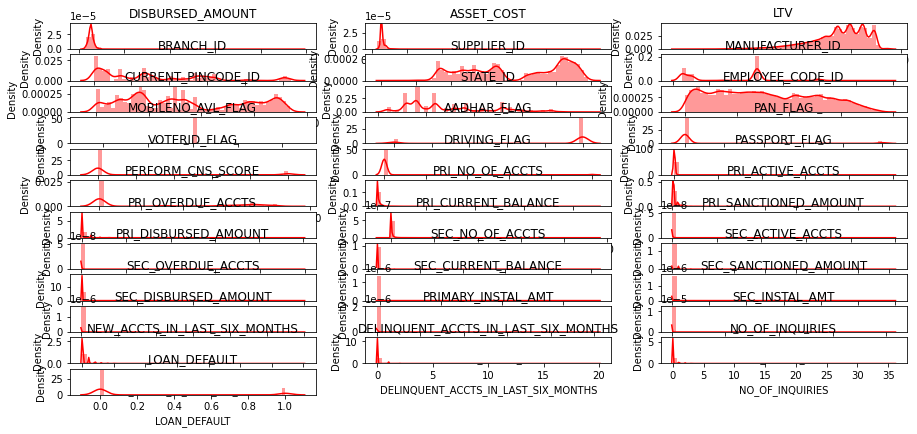

skewness


DISBURSED_AMOUNT                         4.492240
ASSET_COST                               6.133485
LTV                                     -1.075766
BRANCH_ID                                1.027481
SUPPLIER_ID                             -0.168908
MANUFACTURER_ID                          0.388980
CURRENT_PINCODE_ID                       0.278185
STATE_ID                                 0.821971
EMPLOYEE_CODE_ID                         0.244313
MOBILENO_AVL_FLAG                        0.000000
AADHAR_FLAG                             -1.858117
PAN_FLAG                                 3.211462
VOTERID_FLAG                             2.017136
DRIVING_FLAG                             6.328475
PASSPORT_FLAG                           21.611957
PERFORM_CNS_SCORE                        0.445150
PRI_NO_OF_ACCTS                          9.744845
PRI_ACTIVE_ACCTS                         5.371850
PRI_OVERDUE_ACCTS                        7.512927
PRI_CURRENT_BALANCE                     29.425813


In [8]:
df_num= df.select_dtypes(include=np.number)

nrows=14
ncols=3
iterator=1
for i in df_num.columns:
    plt.figsize=(15,8)
    plt.subplot(nrows,ncols,iterator)
    sns.distplot(df_num.loc[:,i],color='red')
    plt.title(i)
    iterator+=1
plt.tight_layout()
plt.show()


print('skewness')

df.drop('LOAN_DEFAULT', axis = 1).skew()

**Interpretation:** The above plot indicates that all the variables are  not normally distributed.


**Distribution of categoric independent variable.**

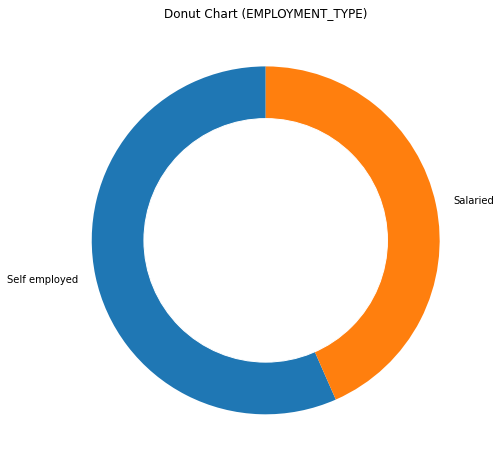

In [9]:
value_= df['EMPLOYMENT_TYPE'].value_counts()
labels = value_.index
sizes = value_.values


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, startangle=90)

# Add a title
plt.title("Donut Chart (EMPLOYMENT_TYPE)") 

# Add a circle at the center
my_circle=plt.Circle( (0,0), 0.7, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)

plt.show()

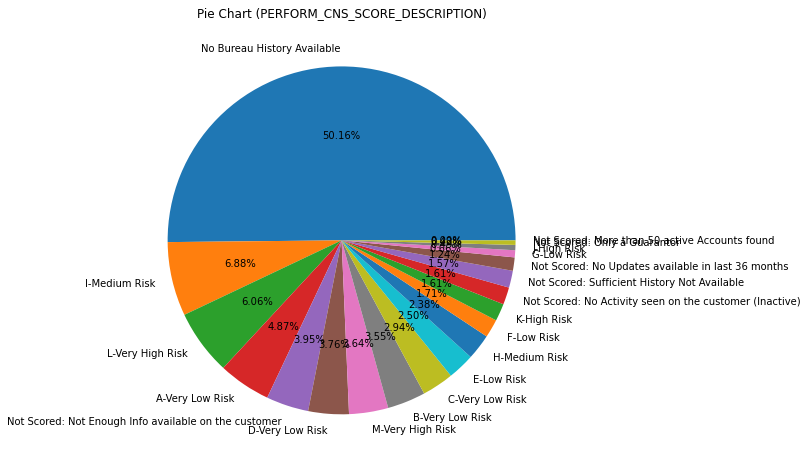

In [10]:
plt.title("Pie Chart (PERFORM_CNS_SCORE_DESCRIPTION)")

plt.pie(df['PERFORM_CNS_SCORE_DESCRIPTION'].value_counts(),labels=df['PERFORM_CNS_SCORE_DESCRIPTION'].unique(),autopct='%.2f%%')
plt.show()

**Interpretation:**
1) Self-employed customers have taken more loans as compared to salaried customers.

2) We can see a lot of categories in PERFORM_CNS_SCORE_DESCRIPTION column so we need to bin the categories accordingly.

--------------------

### BIVARIATE ANALYSIS

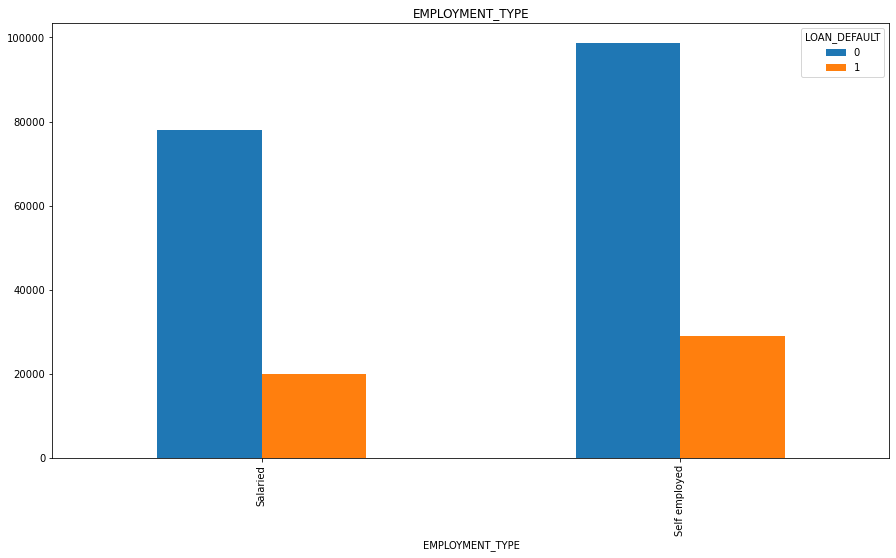

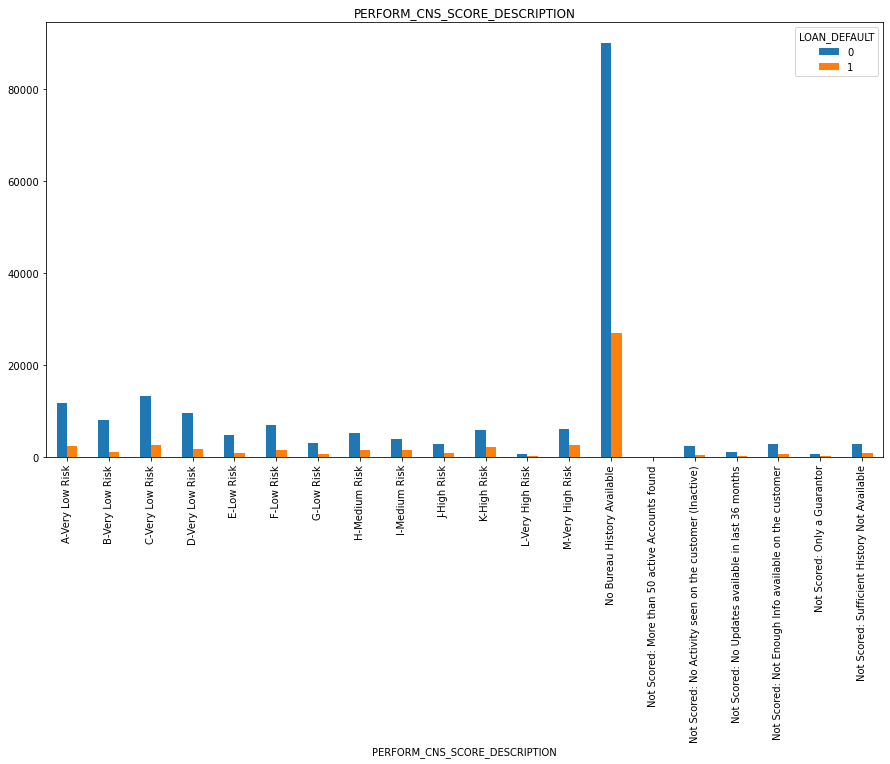

In [11]:
valicat_cols=['EMPLOYMENT_TYPE','PERFORM_CNS_SCORE_DESCRIPTION']

for i in cat_cols:
    pd.crosstab(df.loc[:,i],df.LOAN_DEFAULT).plot(kind='bar')
    plt.title(i)
    plt.show()

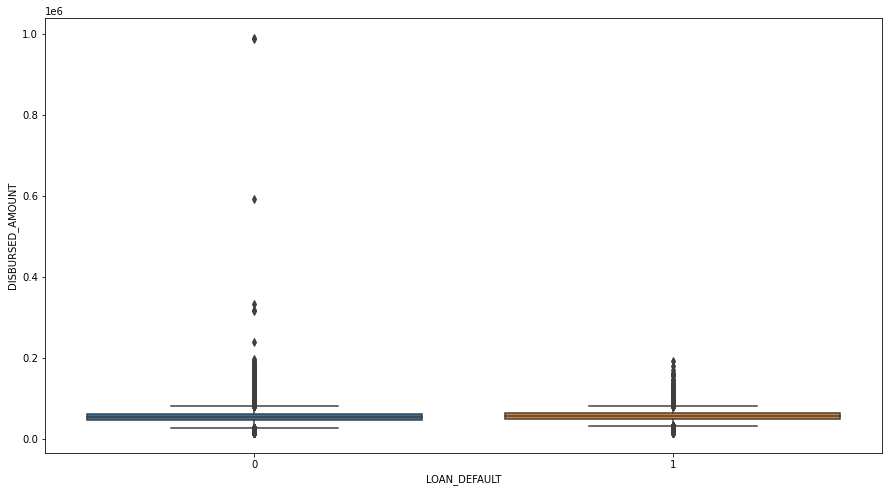

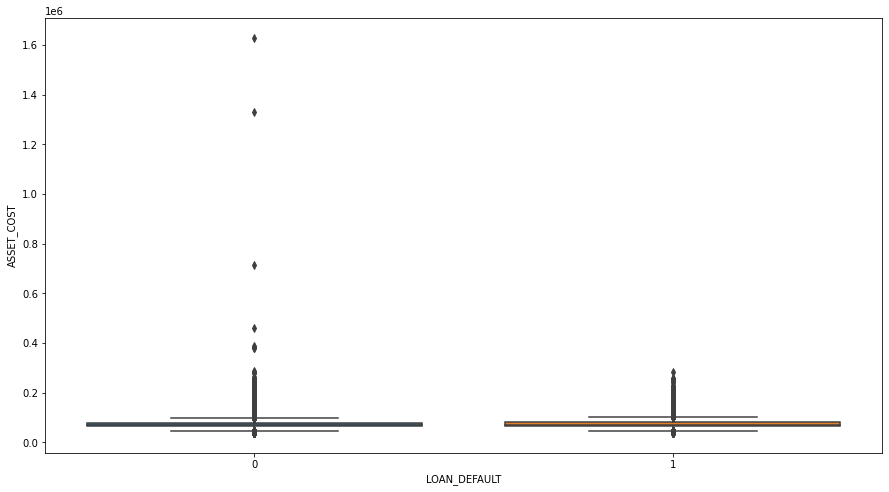

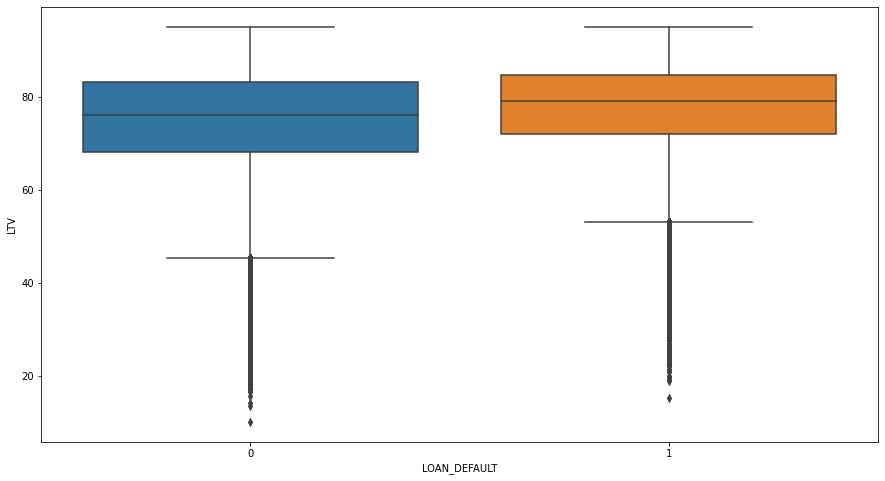

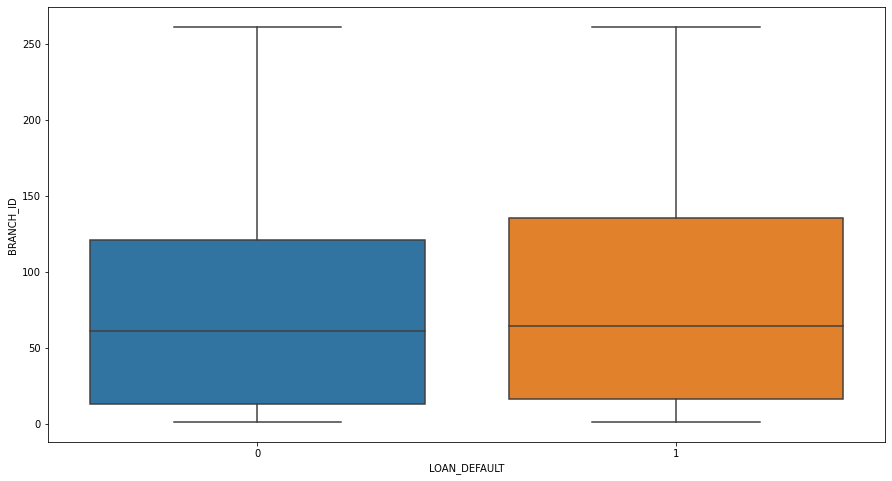

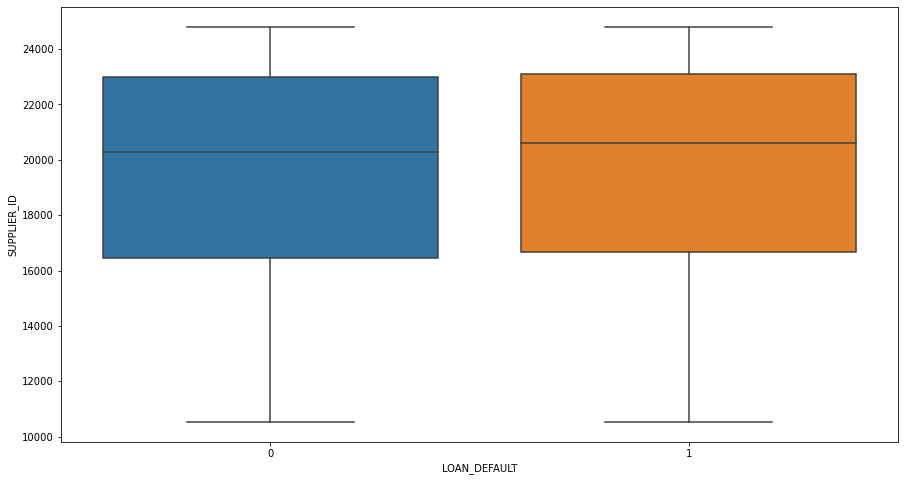

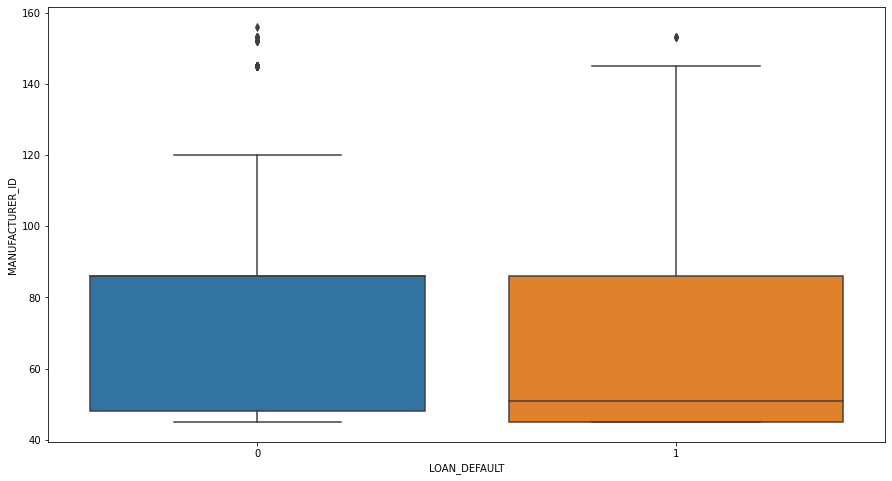

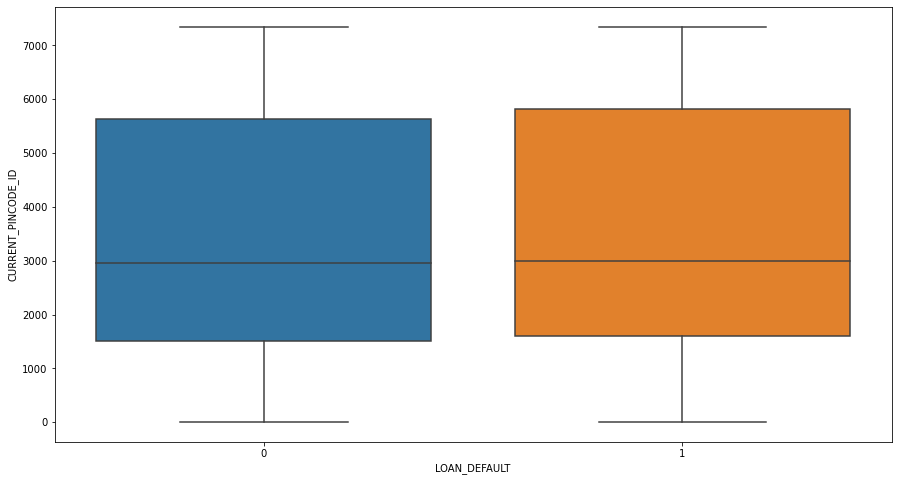

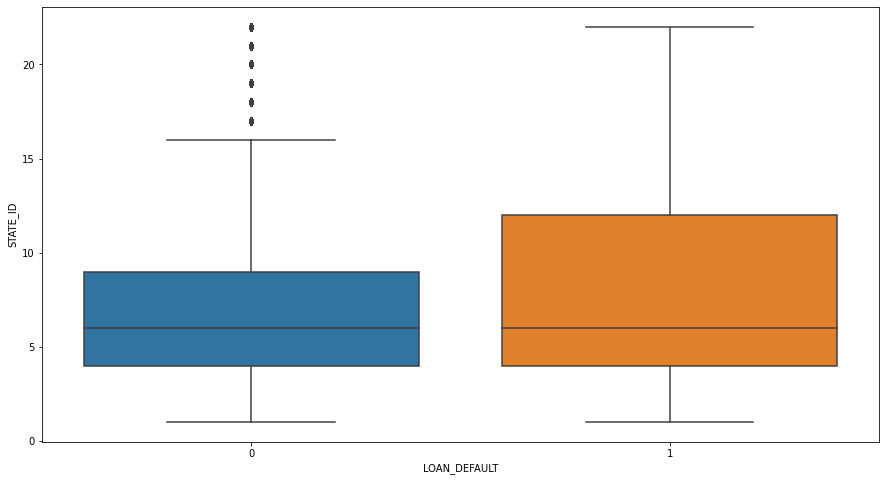

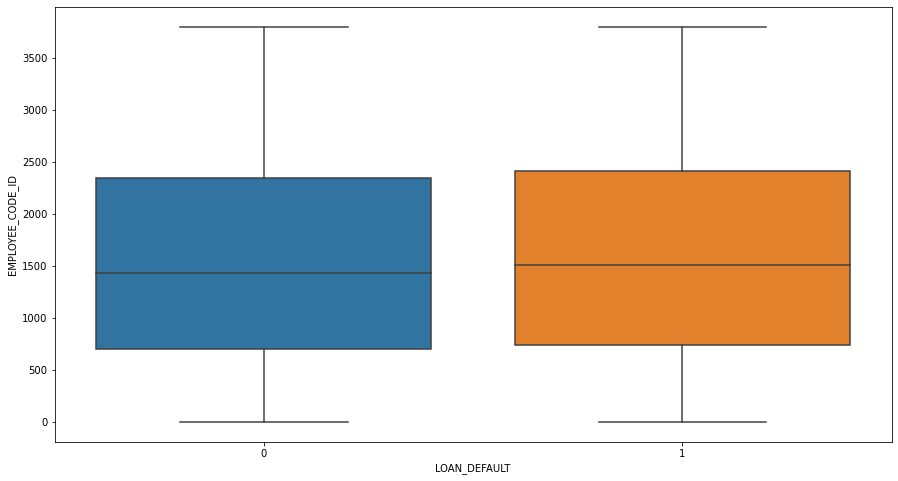

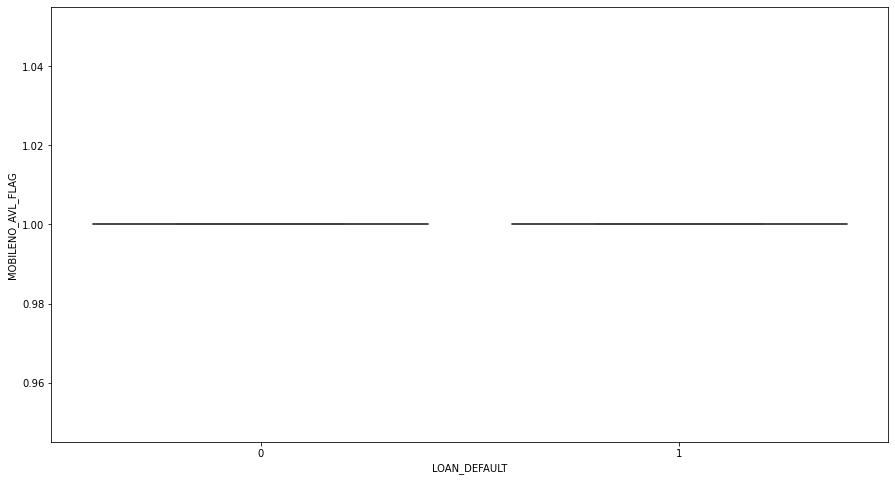

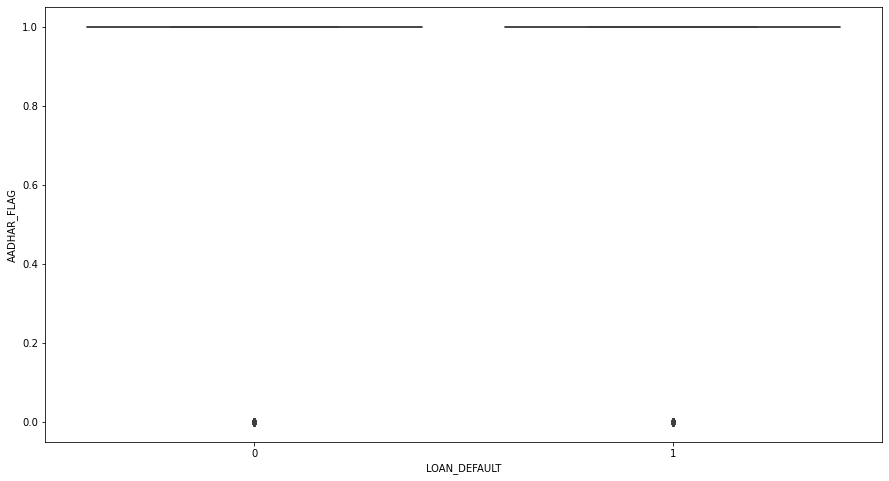

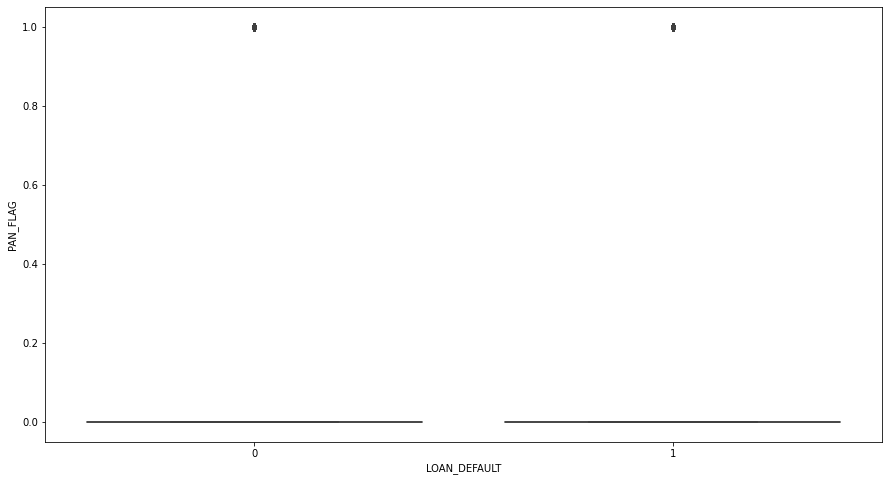

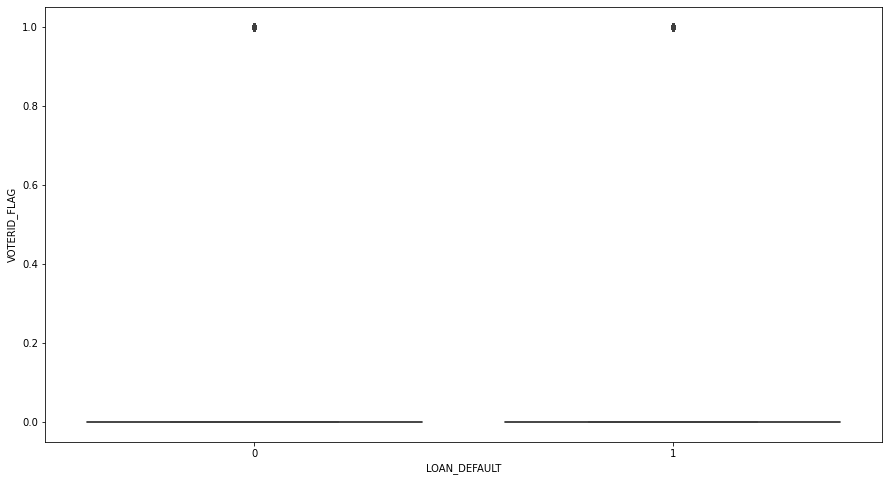

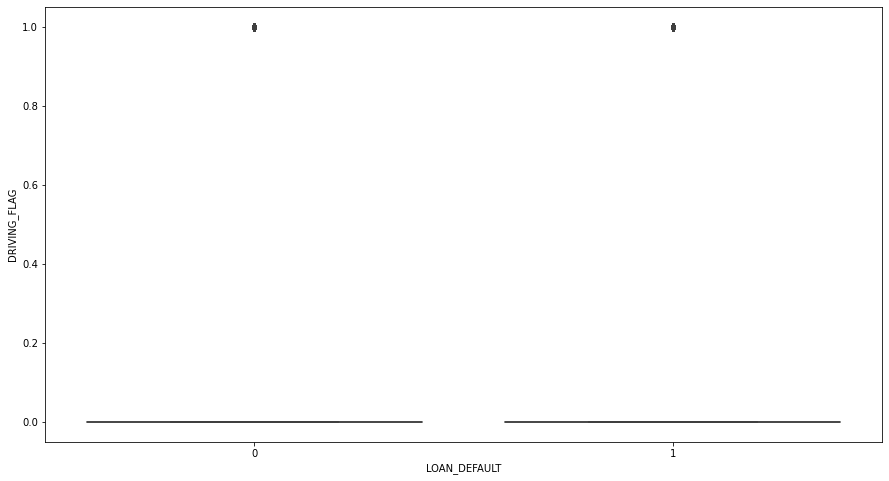

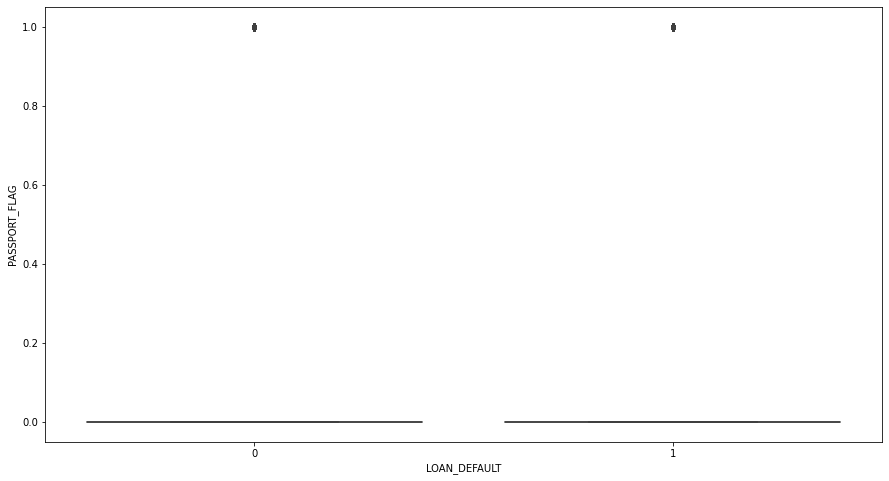

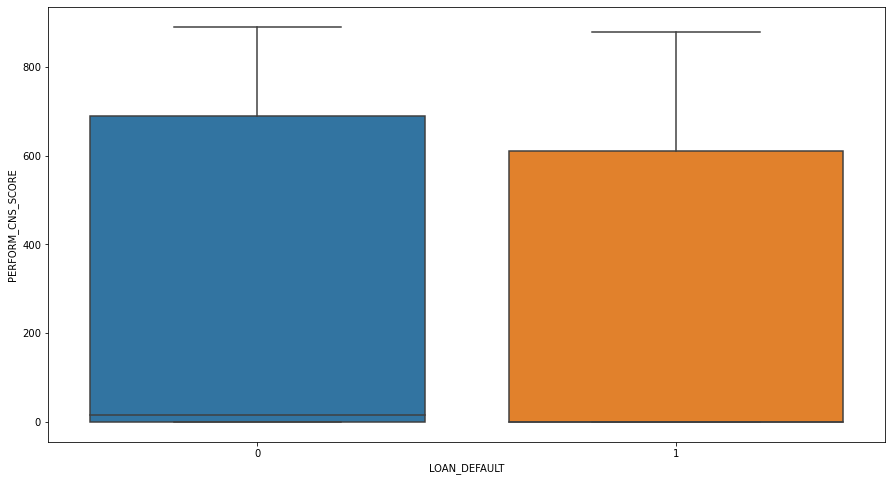

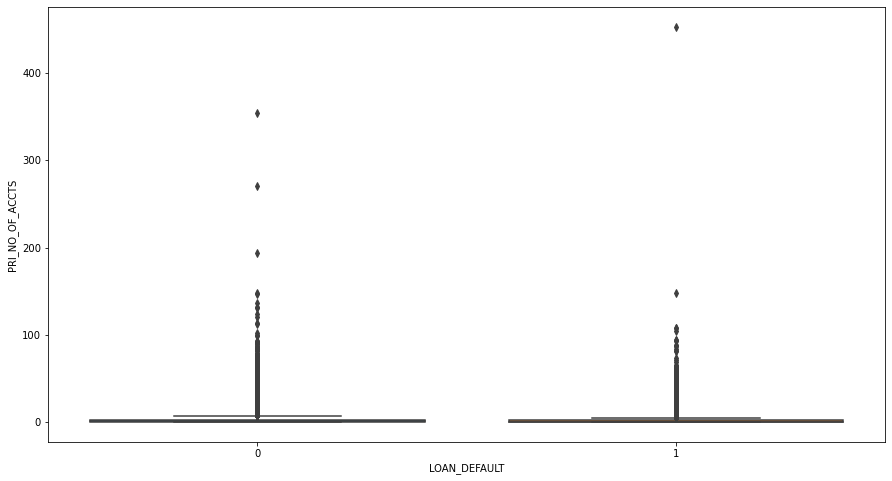

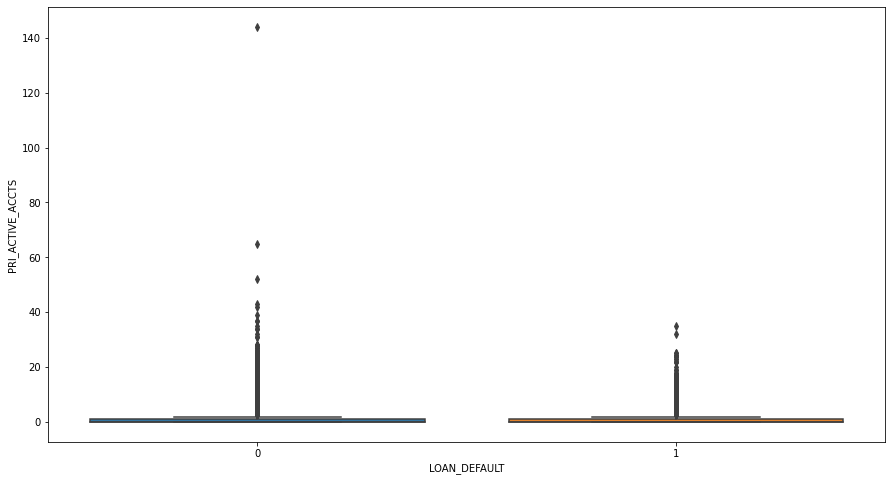

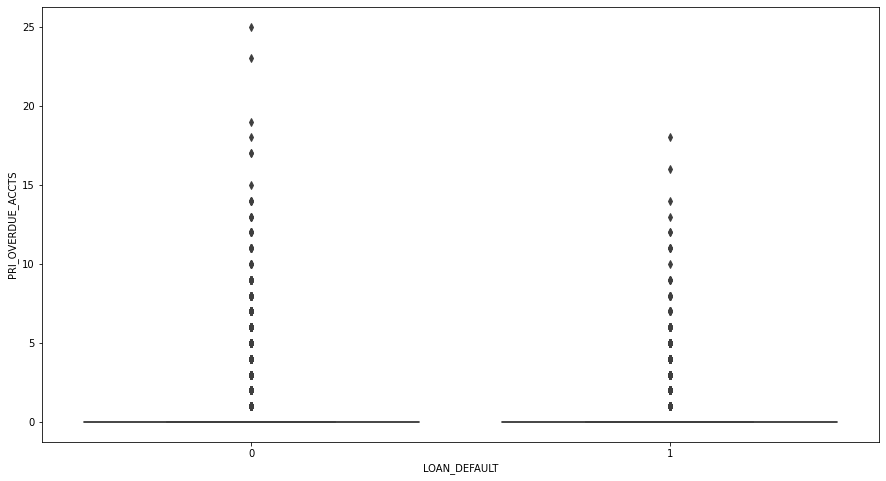

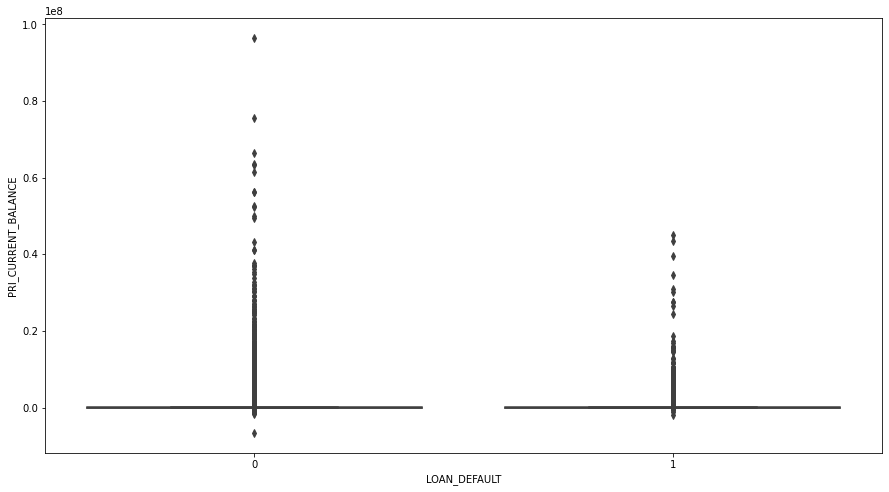

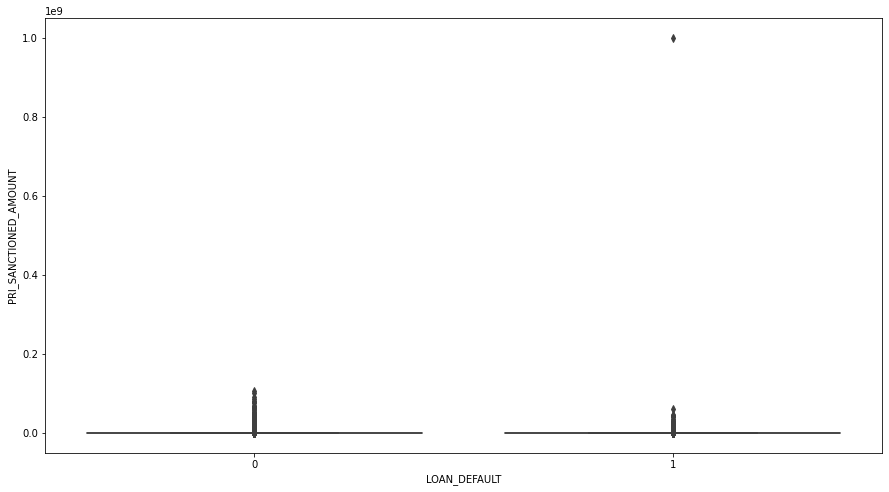

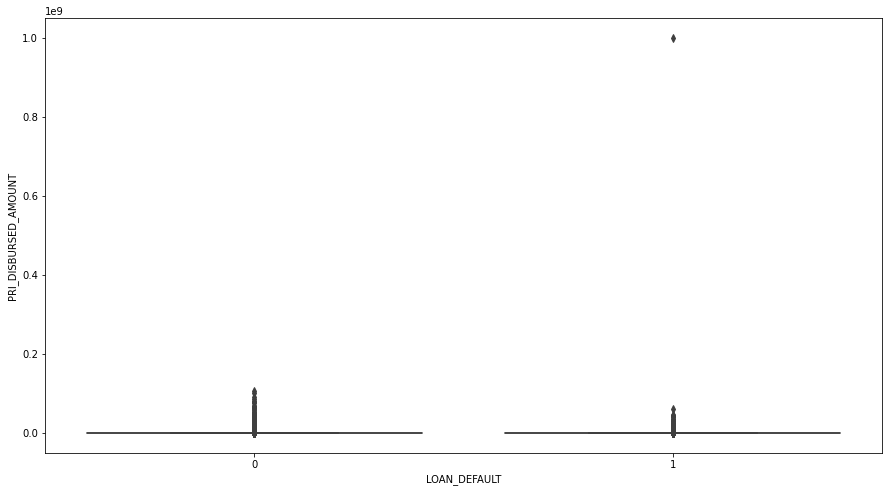

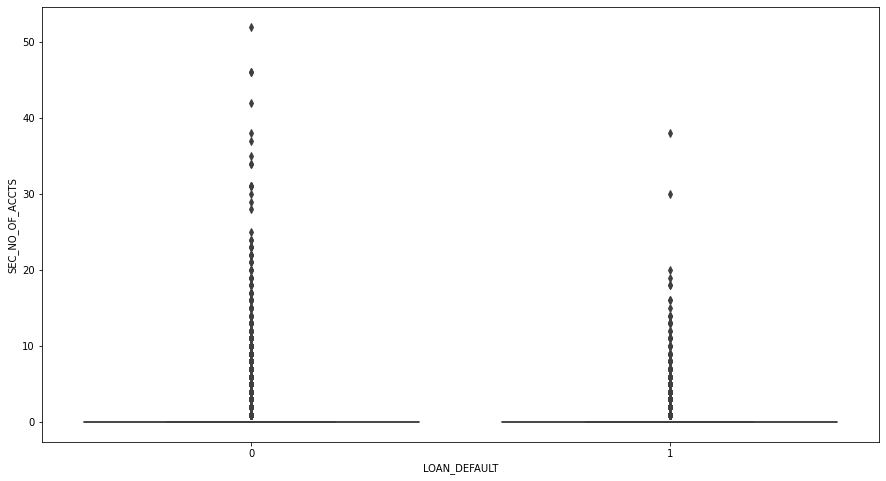

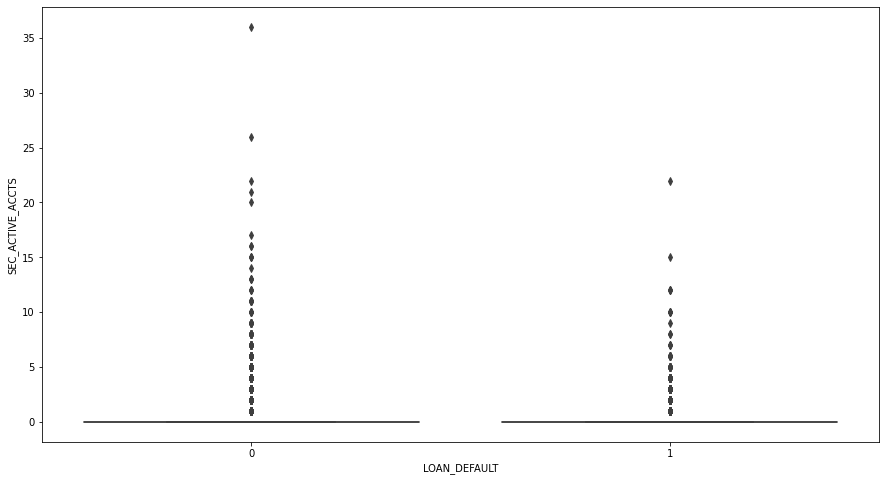

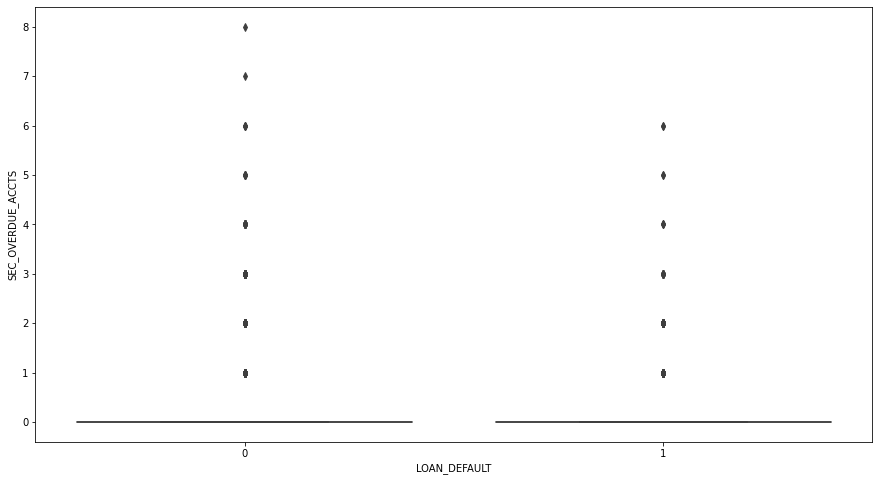

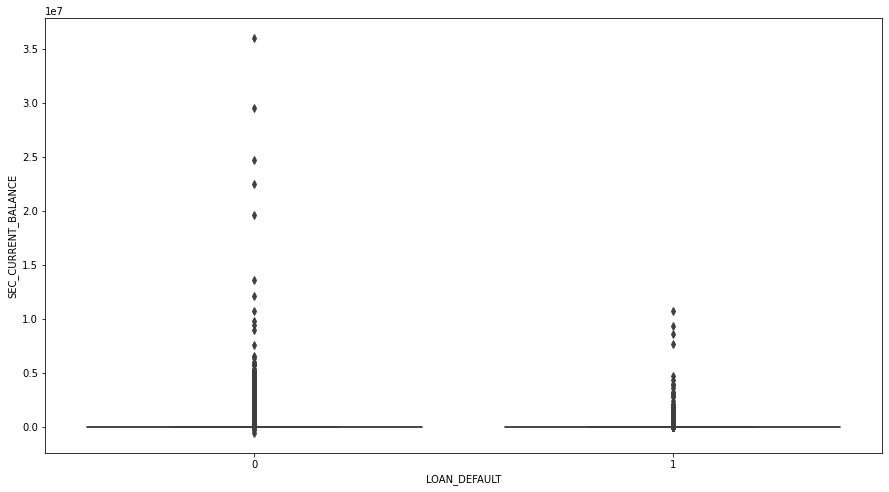

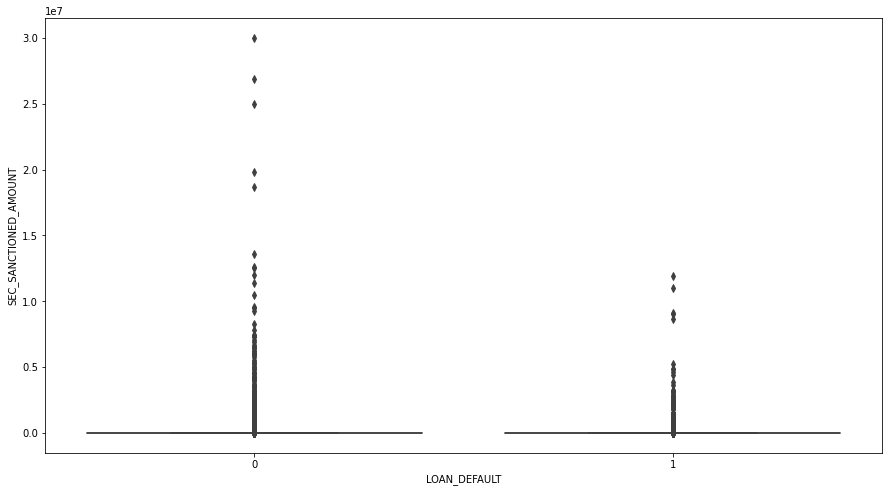

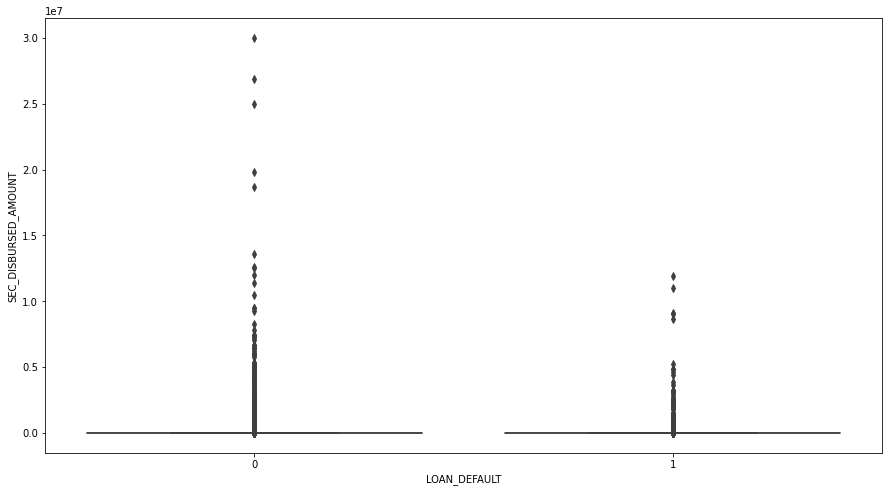

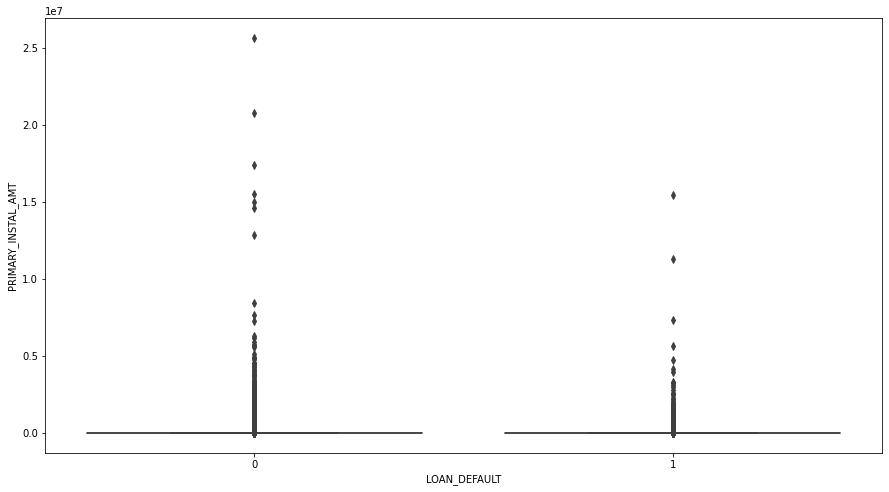

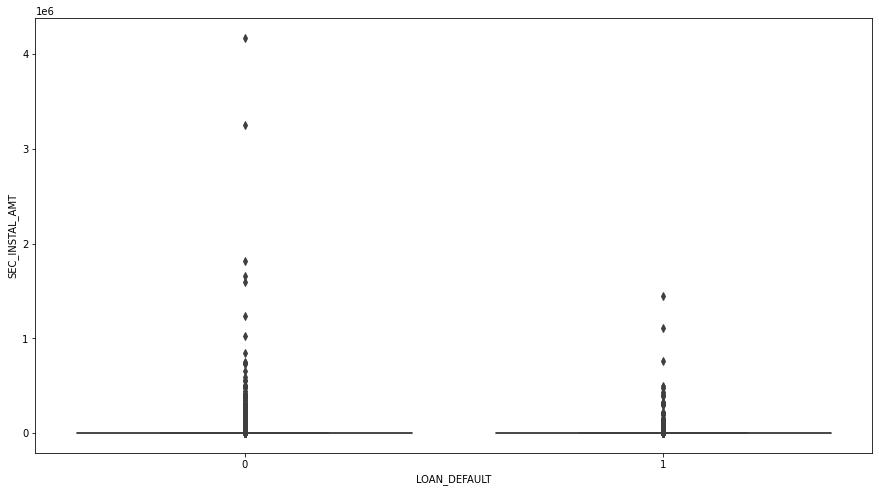

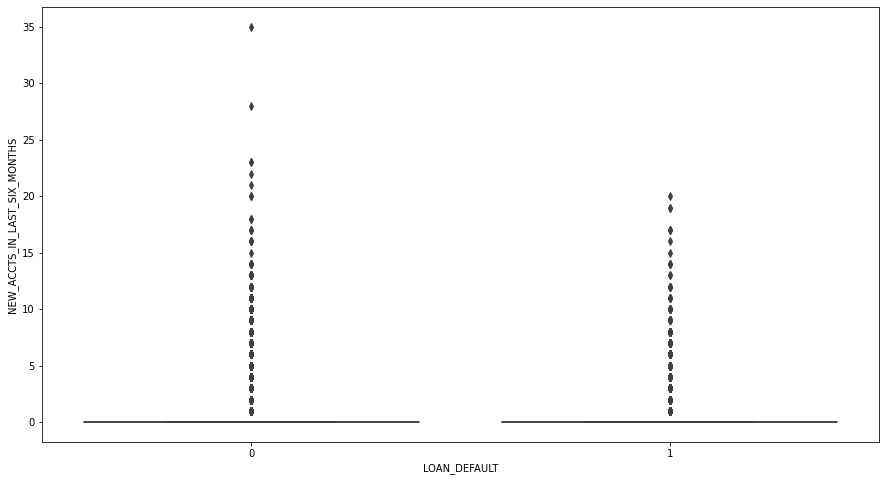

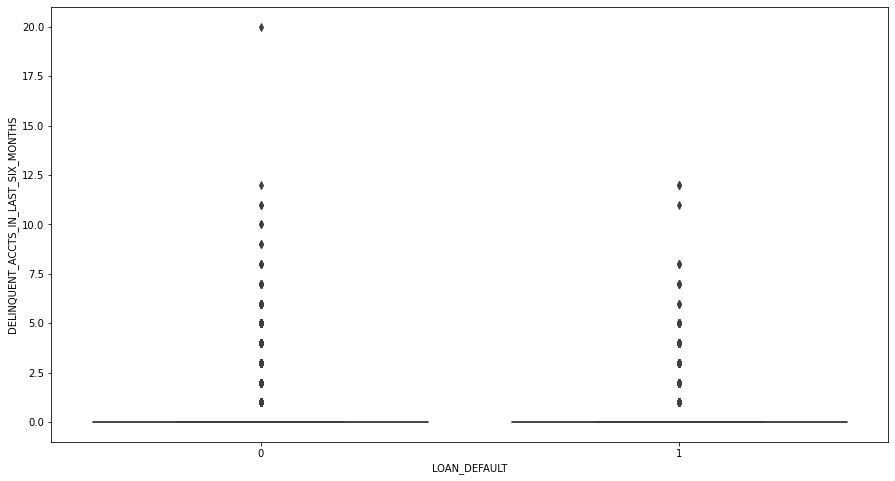

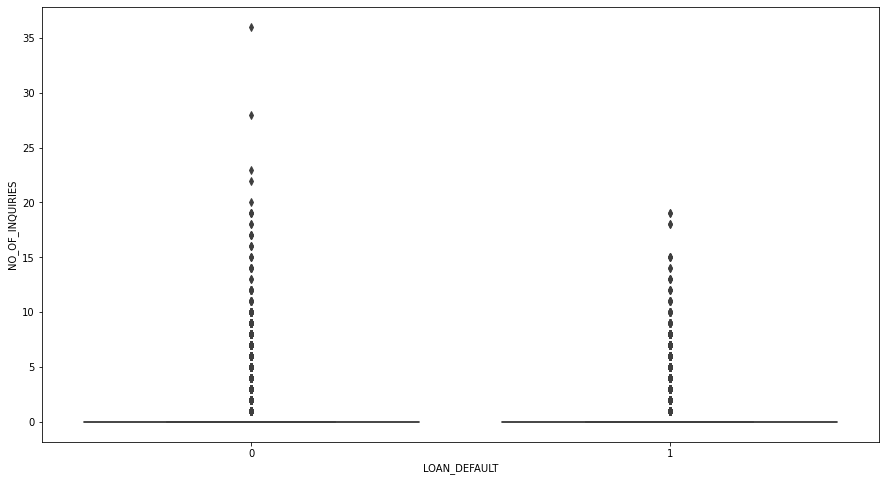

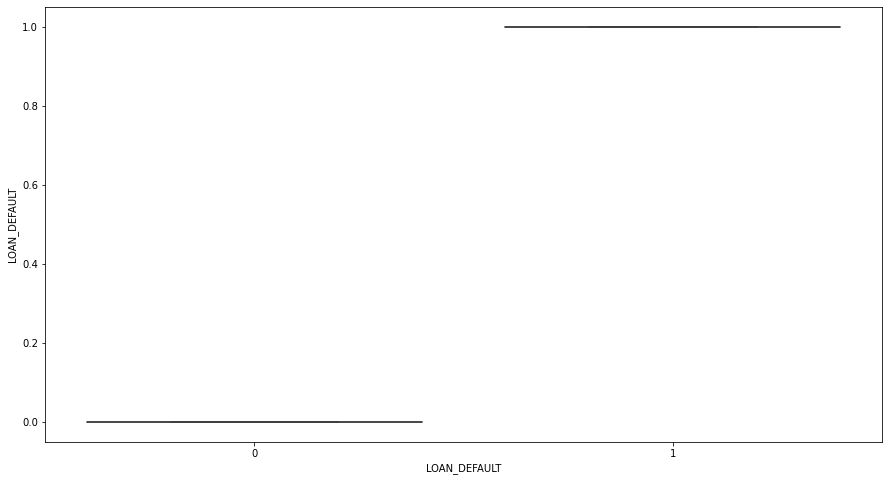

In [12]:
for i in df_num.columns:
    sns.boxplot(df.LOAN_DEFAULT,df.loc[:,i])
    plt.show()

#### Distribution of dependent variable.

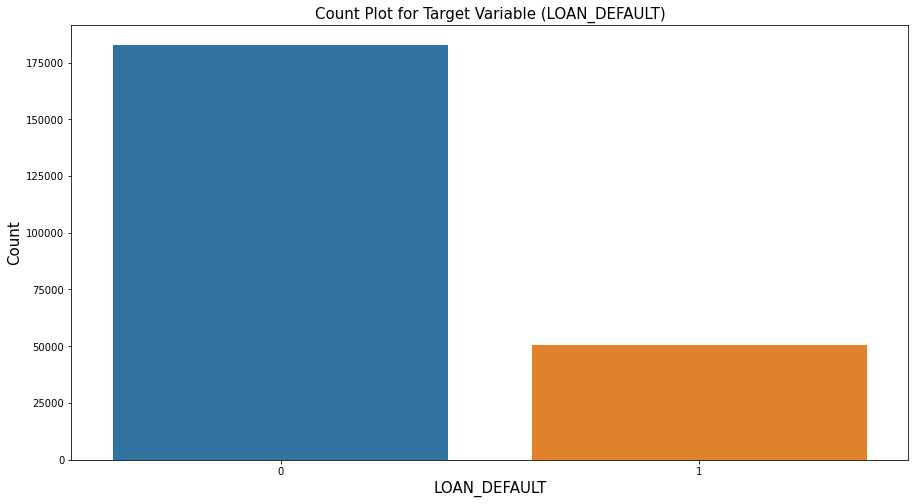

In [13]:
sns.countplot(df.LOAN_DEFAULT)


plt.title('Count Plot for Target Variable (LOAN_DEFAULT)', fontsize = 15)
plt.xlabel('LOAN_DEFAULT', fontsize = 15)
plt.ylabel('Count', fontsize = 15)


plt.show()

<a id="null"></a>
## 2.5 Missing Value Treatment

In [14]:
Total = df.isnull().sum().sort_values(ascending=False) 
Percent = (df.isnull().sum()*100/df.isnull().count()).sort_values(ascending=False)  
missing_data = pd.concat([Total, Percent], axis = 1, keys = ['Total', 'Percentage of Missing Values'])    
missing_data.head()

,Total,Percentage of Missing Values
EMPLOYMENT_TYPE,7661,3.285811
DISBURSED_AMOUNT,0,0.000000
SEC_SANCTIONED_AMOUNT,0,0.000000
PRI_CURRENT_BALANCE,0,0.000000
PRI_SANCTIONED_AMOUNT,0,0.000000


**Interpretation:** The above output shows that there are missing values in the column `EMPLOYMENT_TYPE`.

In [15]:
df['EMPLOYMENT_TYPE']=df['EMPLOYMENT_TYPE'].fillna('Unknown')

The missing values is filled by creating a third category unknown which represents that the employment type for such applicants is not known.

In [16]:
df['EMPLOYMENT_TYPE'].value_counts()

Self employed    127635
Salaried          97858
Unknown            7661
Name: EMPLOYMENT_TYPE, dtype: int64

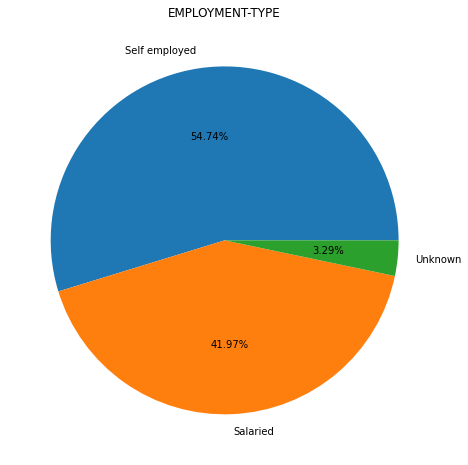

In [17]:
plt.pie(df['EMPLOYMENT_TYPE'].value_counts(),labels= ['Self employed','Salaried','Unknown'],autopct='%0.2f%%')
plt.title('EMPLOYMENT-TYPE')
plt.show()

<a id="outlier"></a>
## 2.6 Outlier Treatment

The dataset contains outliers but it can't be removed because the loan amount and details vary from person
to person and the loan amount they have applied for differs.

<a id="feat_eng"></a>
## 2.7 FEATURE ENGINEERING

### Converting the `AVERAGE_ACCT_AGE` and `CREDIT_HISTORY_LENGTH` into months in order to compare it on comon scale.

In [18]:
p = []
for items in df['AVERAGE_ACCT_AGE'].values: 
    y = int(items[0]) * 12
    if items[6]== 'm':
        m = int(items[5])
    else:
        m = int(items[5:7])
    total = y + m
    p.append(total)

df.loc[:, 'AVERAGE_ACCT_AGE'] = p

In [19]:
l = []
for items in df['CREDIT_HISTORY_LENGTH'].values: 
    y = int(items[0]) * 12
    if items[6]== 'm':
        m = int(items[5])
    else:
        m = int(items[5:7])
    total = y + m
    l.append(total)

df.loc[:, 'CREDIT_HISTORY_LENGTH'] = l

### Creating Age column which represents the age of the loan applicant on the day of disbursement

In [20]:
df['Age']=(df.DISBURSAL_DATE-df.DATE_OF_BIRTH).apply(lambda x: str(x).split(' ')[0]).apply(lambda x: int(x)/365)

In [21]:
df['Age']=df['Age'].astype(int)

### Categorizing the No. of enquiries column which represents enuires done by a customer for loans.

In [22]:
def enquiry(x):
    if x==0:
        return'No enquiry'
    elif(x>=1 and x<=10):
        return 'Less Frequent'
    elif(x>=11 and x<=20):
        return 'Frequent'
    else:
        return 'Very Frequent'

In [23]:
df['FREQUENCY_OF_INQUIRIES']=df['NO_OF_INQUIRIES'].apply(enquiry)

### Creating a ID column which represents the Id proofs given by the loan applicant

In [24]:
df['ID']=  df['PAN_FLAG']+ df['AADHAR_FLAG']



### Binning the `DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS` column into categories

In [25]:
def bins(x):
    if x==0:
        return 'no accounts'
    if x>0 and x<8:
        return 'few accounts'
    if x>=8 and x<15:
        return 'couple of accounts'
    else:
        return 'several accounts'
    
df['Deliquent_accounts'] = df['DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS'].apply(bins)

### Binning the `NEW_ACCTS_IN_LAST_SIX_MONTHS` column into categories

In [26]:
def bins(x):
    if x==0:
        return 'no accounts'
    if x>0 and x<13:
        return 'few accounts'
    if x>=13 and x<25:
        return 'couple of accounts'
    else:
        return 'several accounts'
    
df['New_accounts'] = df['NEW_ACCTS_IN_LAST_SIX_MONTHS'].apply(bins)

### Binning the `PERFORM_CNS_SCORE` column into categories

In [27]:
def scores(x):
    if x==0:
        return 'no score'
    if x>0 and x<300:
        return 'low score'
    if x>=300 and x<600:
        return 'good score'
    else:
        return 'high score'
    
df['credit_score'] = df['PERFORM_CNS_SCORE'].apply(scores)

In [28]:
df.head()

,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,STATE_ID,EMPLOYEE_CODE_ID,MOBILENO_AVL_FLAG,AADHAR_FLAG,PAN_FLAG,VOTERID_FLAG,DRIVING_FLAG,PASSPORT_FLAG,PERFORM_CNS_SCORE,PERFORM_CNS_SCORE_DESCRIPTION,PRI_NO_OF_ACCTS,PRI_ACTIVE_ACCTS,PRI_OVERDUE_ACCTS,PRI_CURRENT_BALANCE,PRI_SANCTIONED_AMOUNT,PRI_DISBURSED_AMOUNT,SEC_NO_OF_ACCTS,SEC_ACTIVE_ACCTS,SEC_OVERDUE_ACCTS,SEC_CURRENT_BALANCE,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT,Age,FREQUENCY_OF_INQUIRIES,ID,Deliquent_accounts,New_accounts,credit_score
0,50578,58400,89.55,67,22807,45,1441,1984-01-01,Salaried,2018-03-08,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34,No enquiry,1,no accounts,no accounts,no score
1,47145,65550,73.23,67,22807,45,1502,1985-07-31,Self employed,2018-09-26,6,1998,1,1,0,0,0,0,598,I-Medium Risk,1,1,1,27600,50200,50200,0,0,0,0,0,0,1991,0,0,1,23,23,0,1,33,No enquiry,1,few accounts,no accounts,good score
2,53278,61360,89.63,67,22807,45,1497,1985-08-24,Self employed,2018-01-08,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32,No enquiry,1,no accounts,no accounts,no score
3,57513,66113,88.48,67,22807,45,1501,1993-12-30,Self employed,2018-10-26,6,1998,1,1,0,0,0,0,305,L-Very High Risk,3,0,0,0,0,0,0,0,0,0,0,0,31,0,0,0,8,15,1,1,24,Less Frequent,1,no accounts,no accounts,good score
4,52378,60300,88.39,67,22807,45,1495,1977-09-12,Self employed,2018-09-26,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,41,Less Frequent,1,no accounts,no accounts,no score


# <a id="feat_selection"></a>
## 2.8 FEATURE SELECTION

In feature selection we search for the significant variables by usind T test for numerical variables and chi2 test for 
categorical variable.


In [29]:
df_num= df.select_dtypes(include=np.number)

significant_num_columns=[]
insignificant_num_columns=[]

for i in df_num:
    zero= df_num.loc[df_num.LOAN_DEFAULT==0, i]
    one= df_num.loc[df_num.LOAN_DEFAULT==1, i]
    
    test_stats, pval= stats.ttest_ind(zero,one)
   
        
    if pval <0.05:
        significant_num_columns.append(i)
    else:
        insignificant_num_columns.append(i)
        
significant_num_columns= pd.DataFrame(significant_num_columns)
insignificant_num_columns= pd.DataFrame(insignificant_num_columns)


significant_num_columns



,0
0,DISBURSED_AMOUNT
1,ASSET_COST
2,LTV
3,BRANCH_ID
4,SUPPLIER_ID
5,MANUFACTURER_ID
6,CURRENT_PINCODE_ID
7,STATE_ID
8,EMPLOYEE_CODE_ID
9,AADHAR_FLAG


In [30]:
df_cat= df.select_dtypes(include='object')

significant_cat_columns=[]
insignificant_cat_columns=[]


j=1
for i in df_cat:
    if i != 'LOAN_DEFAULT':
        tb1= pd.crosstab(df[i], df['LOAN_DEFAULT'])
        
        t, pval,_,_ = stats.chi2_contingency(tb1)
        
        if pval <0.05:
            significant_cat_columns.append(i)
        else:
            insignificant_car_columns.append(i)
        
significant_cat_columns= pd.DataFrame(significant_cat_columns)
insignificant_cat_columns= pd.DataFrame(insignificant_cat_columns)


significant_cat_columns


,0
0,EMPLOYMENT_TYPE
1,PERFORM_CNS_SCORE_DESCRIPTION
2,FREQUENCY_OF_INQUIRIES
3,Deliquent_accounts
4,New_accounts
5,credit_score


After performing statistical test we can see that there are few numeric columns which are insignificant. Thus we drop 
those columns as they provide no information for prediction on loan defaults.

In [31]:
Final_data= df.drop(['MOBILENO_AVL_FLAG','PAN_FLAG','SEC_OVERDUE_ACCTS','SEC_INSTAL_AMT'],axis=1)


Further we also drop these columns-

1. `DATE_OF_BIRTH` and `DISBURSAL_DATE` because by using these two columns we have created the age. Thus we can drop these.


2. `PERFORM_CNS_SCORE` and `PERFORM_CNS_SCORE_DESCRIPTION` because the column credit score is been created by considering these
two in account. Thus we drop these.


3. `AADHAR_FLAG','PAN_FLAG','VOTERID_FLAG','DRIVING_FLAG','PASSPORT_FLAG'` because the variable Id is been created by taking
into account all these columns.

4. `NO_OF_INQUIRIES, DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS, NEW_ACCTS_IN_LAST_SIX_MONTHS

In [32]:
Final_data= Final_data.drop(['DATE_OF_BIRTH','DISBURSAL_DATE','AADHAR_FLAG','PERFORM_CNS_SCORE','PERFORM_CNS_SCORE_DESCRIPTION',
                   'VOTERID_FLAG','DRIVING_FLAG','PASSPORT_FLAG','NO_OF_INQUIRIES', 'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS',
                     'NEW_ACCTS_IN_LAST_SIX_MONTHS'],axis=1)

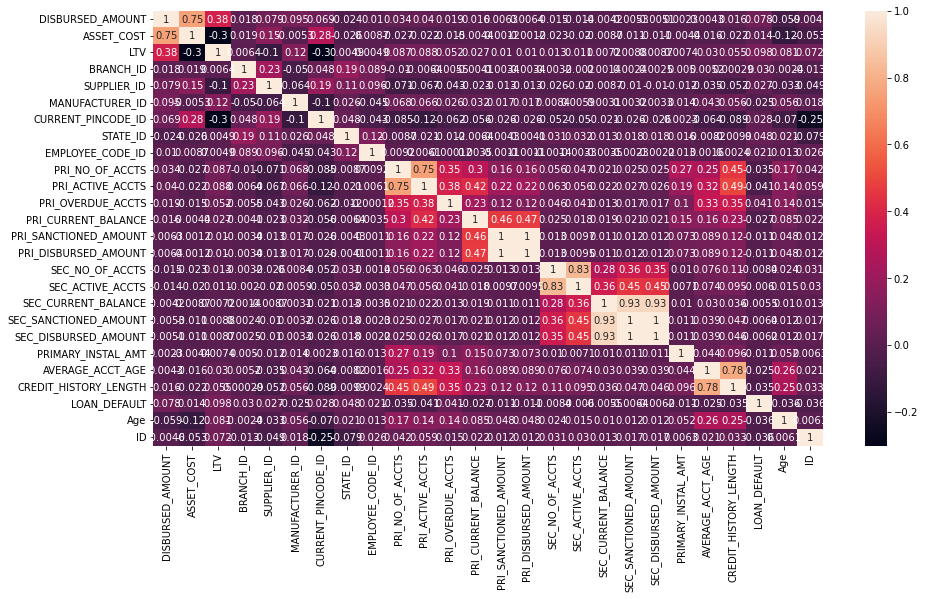

In [33]:
sns.heatmap(Final_data.corr(),annot=True)
plt.show()

<a id="dummy"></a>
## 2.9  Encode the Categorical Variables

We encode the categoric variables so that the machine learning models can learn from it and provide accurate predictions.

In [34]:
le= LabelEncoder()

In [35]:
df_cat= Final_data.select_dtypes(include='object')

df_cat = pd.get_dummies(df['EMPLOYMENT_TYPE'], drop_first = True)

df_cat['FREQUENCY_OF_INQUIRIES'] = le.fit_transform(df['FREQUENCY_OF_INQUIRIES'])
df_cat['Deliquent_accounts'] = le.fit_transform(df['Deliquent_accounts'])
df_cat['New_accounts'] = le.fit_transform(df['New_accounts'])
df_cat['credit_score'] = le.fit_transform(df['credit_score'])

In [36]:
df_cat.head()

,Self employed,Unknown,FREQUENCY_OF_INQUIRIES,Deliquent_accounts,New_accounts,credit_score
0,0,0,2,2,2,3
1,1,0,2,1,2,0
2,1,0,2,2,2,3
3,1,0,1,2,2,0
4,1,0,1,2,2,3


<a id="scale"></a>
## 2.10 Scaling the numeric Data

Scaling of numeric data is done to ensure that every variable is in the equal scale and does not dominate the preditions.

In [2]:
df_num= Final_data.select_dtypes(include=np.number)

df_num= df_num.drop('LOAN_DEFAULT',axis=1)

ss= StandardScaler()


num_scaled = ss.fit_transform(df_num)


df_num_scaled = pd.DataFrame(num_scaled, columns = df_num.columns)

NameError: name 'Final_data' is not defined

Now we combine the scaled and encoded data.

In [38]:
Scaled_data = pd.concat([df_num_scaled, df_cat], axis = 1)

Scaled_data['LOAN_DEFAULT']= df['LOAN_DEFAULT']

<a id="split"></a>
## 2.11 Train-Test Split

The train-test split is used to estimate the performance of machine learning algorithms 
that are applicable for prediction-based Algorithms/Applications. This method is a fast and easy procedure 
to perform such that we can compare our own machine learning model results to machine results.

In [39]:
x= Scaled_data.drop('LOAN_DEFAULT',axis=1)
y= Scaled_data['LOAN_DEFAULT']

As we saw above that the target variable is highly imbalanced so we perform smote analysis to make the data balance.

In [40]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_res,y_res=smote.fit_resample(x,y)

In [41]:
x_train, x_test, y_train, y_test= train_test_split(x_res,y_res, test_size=0.3, random_state=9)

print('X_train', x_train.shape)
print('y_train', y_train.shape)

print('X_test', x_test.shape)
print('y_test', y_test.shape)

X_train (255560, 31)
y_train (255560,)
X_test (109526, 31)
y_test (109526,)


<a id="models"></a>
# 3. Model Building

<a id="decision"></a>
## 3.1 Decision Tree

In [42]:
decision_tree_classification = DecisionTreeClassifier(criterion = 'entropy', random_state = 10)

decision_tree = decision_tree_classification.fit(x_train, y_train)

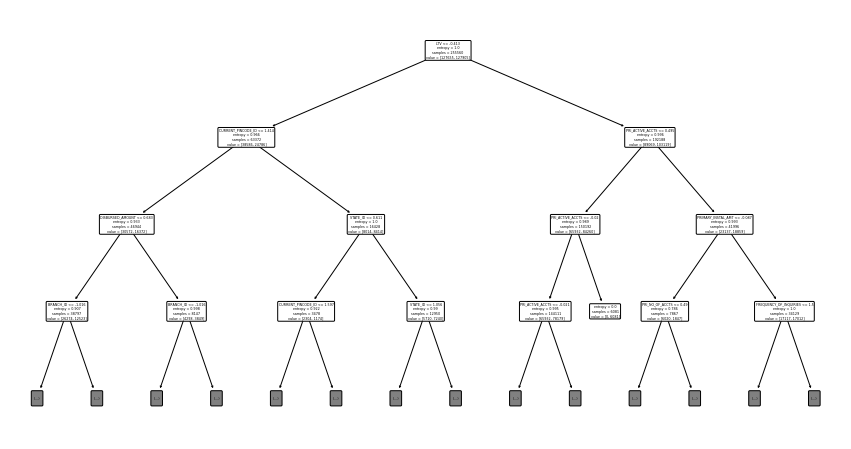

In [43]:
tree.plot_tree(decision_tree,max_depth=3,feature_names=x_train.columns,rounded=True)
plt.show()

In [44]:
y_pred_test= decision_tree.predict(x_test)
y_pred_train= decision_tree.predict(x_train)

In [45]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.75      0.72      0.73     54888
           1       0.73      0.75      0.74     54638

    accuracy                           0.74    109526
   macro avg       0.74      0.74      0.74    109526
weighted avg       0.74      0.74      0.74    109526



In [46]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127655
           1       1.00      1.00      1.00    127905

    accuracy                           1.00    255560
   macro avg       1.00      1.00      1.00    255560
weighted avg       1.00      1.00      1.00    255560



<a id="rf"></a>
## 3.2 Random Forest

In [47]:
rf_classification = RandomForestClassifier(n_estimators = 10, random_state = 10)


rf_model = rf_classification.fit(x_train, y_train)

In [48]:
y_pred= rf_model.predict(x_test)

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.85      0.81     54888
           1       0.83      0.74      0.78     54638

    accuracy                           0.79    109526
   macro avg       0.80      0.79      0.79    109526
weighted avg       0.80      0.79      0.79    109526



<a id="knn"></a>
## 3.3 K- neighbors Classifier

In [50]:
knn_classification = KNeighborsClassifier(n_neighbors = 1)


knn_model = knn_classification.fit(x_train, y_train)

In [51]:
y_pred= knn_model.predict(x_test)

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     54888
           1       0.74      0.94      0.83     54638

    accuracy                           0.81    109526
   macro avg       0.83      0.81      0.81    109526
weighted avg       0.83      0.81      0.81    109526



In [53]:
knn_classification = KNeighborsClassifier(n_neighbors = 2)


knn_model = knn_classification.fit(x_train, y_train)

In [54]:
y_pred= knn_model.predict(x_test)

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80     54888
           1       0.79      0.82      0.80     54638

    accuracy                           0.80    109526
   macro avg       0.80      0.80      0.80    109526
weighted avg       0.80      0.80      0.80    109526



<a id="ada"></a>
## 3.4 AdaBoost Classifier

In [56]:
ada_model = AdaBoostClassifier(n_estimators = 40, random_state = 10)


ada_model.fit(x_train, y_train)

AdaBoostClassifier(n_estimators=40, random_state=10)

In [57]:
y_pred= ada_model.predict(x_test)

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.63      0.65     54888
           1       0.65      0.68      0.66     54638

    accuracy                           0.65    109526
   macro avg       0.65      0.65      0.65    109526
weighted avg       0.65      0.65      0.65    109526



<a id="gb"></a>
## 3.5 Gradient Boost Classifier

In [59]:
gboost_model = GradientBoostingClassifier(n_estimators = 150, random_state = 10)


gb = gboost_model.fit(x_train, y_train)

In [60]:
y_pred= gb.predict(x_test)

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.79     54888
           1       0.81      0.73      0.77     54638

    accuracy                           0.78    109526
   macro avg       0.78      0.78      0.78    109526
weighted avg       0.78      0.78      0.78    109526



<a id="tune"></a>
### 3.3.1 Tune the Hyperparameters (GridSearchCV)

Hyperparameters are the parameters in the model that are preset by the user. GridSearch considers all the combinations of hyperparameters and returns the best hyperparameter values. We pass some of the hyperparameters in the K-neighbors classifier to the ` GridSearchCV()` and build the model using the optimal values obtained using GridSearch method.

Tuning the hyperparameter of K- neighbors Classifier.

In [62]:
tuned_paramaters = {'n_neighbors': range(1,5)}
 
knn_classification = KNeighborsClassifier()


knn_grid = GridSearchCV(estimator = knn_classification, 
                        param_grid = tuned_paramaters, 
                        cv = 5, 
                        scoring = 'accuracy')


knn_grid.fit(x_train, y_train)


print('Best parameters for KNN Classifier: ', knn_grid.best_params_, '\n')

Best parameters for KNN Classifier:  {'n_neighbors': 1} 



the best value for the parameter n neighbors is 1. Further we make a final model using the optimal value of parameters.

# Final Model

In [63]:
knn_classification = KNeighborsClassifier(n_neighbors = 1)


knn_model = knn_classification.fit(x_train, y_train)

In [64]:
y_pred= knn_model.predict(x_test)

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     54888
           1       0.74      0.94      0.83     54638

    accuracy                           0.81    109526
   macro avg       0.83      0.81      0.81    109526
weighted avg       0.83      0.81      0.81    109526



Plotting the confusion matrix for the Final model

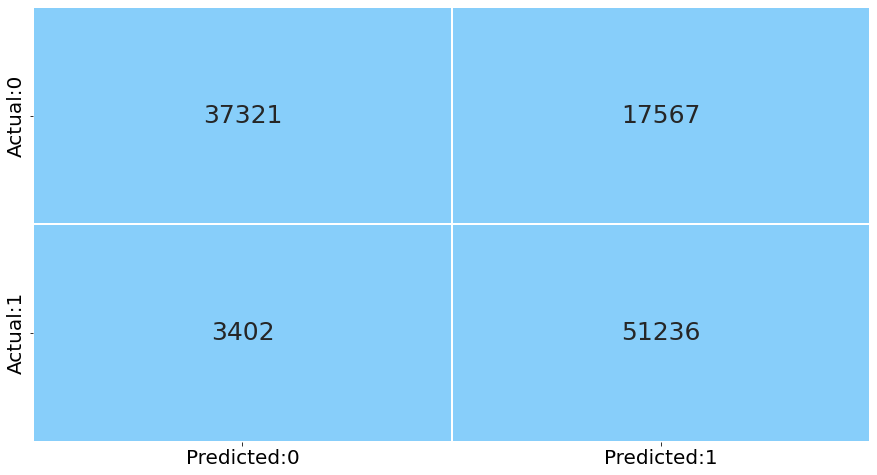

In [66]:
cm = confusion_matrix(y_test, y_pred)

conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])

sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = ListedColormap(['lightskyblue']), cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})

plt.xticks(fontsize = 20)


plt.yticks(fontsize = 20)


plt.show()

Kappa score: It is a measure of inter-rater reliability. For logistic regression, the actual and predicted values of the target variable are the raters.

In [67]:
kappa = cohen_kappa_score(y_test, y_pred)


print('kappa value:',kappa)

kappa value: 0.6173194279922914


**Interpretation:** As the kappa score for the full model (with cut-off probability 0.5) is 0.6125, we can say that there is substantial agreement between the actual and predicted values.

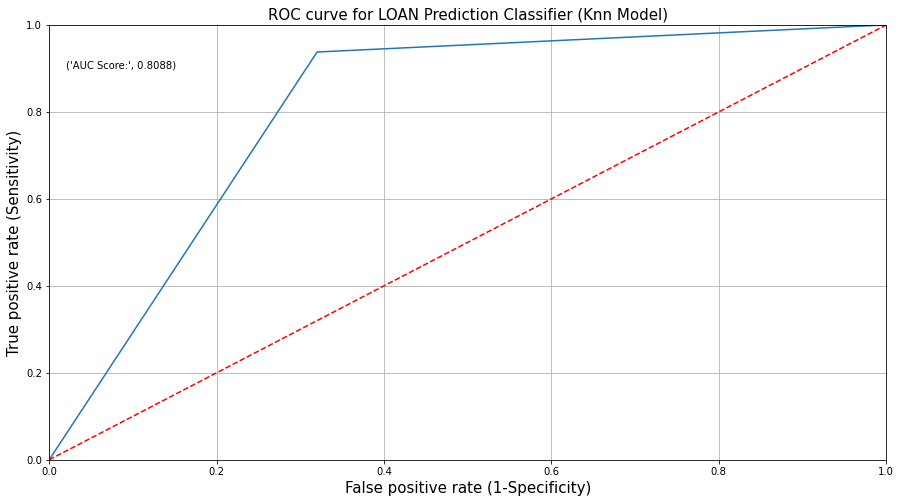

In [68]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)


plt.plot(fpr, tpr)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])


plt.plot([0, 1], [0, 1],'r--')


plt.title('ROC curve for LOAN Prediction Classifier (Knn Model)', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)

\
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(y_test, y_pred),4)))

plt.grid(True)

**Interpretation:** The red dotted line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).<br>
From the above plot, we can see that our classifier (knn_model with n_neighbors = 1) is away from the dotted line; with the AUC score 0.8064.

# Conclusion

To evaluate the success of these models, common evaluation metrics such as accuracy, precision, recall, and F1 score can be used. It is also important to consider the robustness of the solution by testing the models on dataset and ensuring that they generalize well to unseen data.

When choosing a machine learning model, there are many factors to consider. Some important ones include accuracy, recall, precision, and the trade-off between false positives and false negatives. In general, a model with higher accuracy is preferred, but sometimes a model with a high recall for a particular class may be more important, depending on the specific application.

After comparing all the models we can see that we need to predict the outcome whether the loan defaulted or not, so the recall for 1 was important in this case and here we can see that kNN recall for 1 is better than other models which means its better than others at predicting whether the loan will default or not. Hence we choose KNN.

'
KNN, or K-Nearest Neighbors, is a non-parametric method used for classification and regression. It is based on the idea that similar instances should have similar outcomes. In KNN, the prediction for a given data point is based on the K number of points closest to it, where K is a hyperparameter that needs to be specified.








<a id="imp"></a>
# 4. Important Features

The method feature_importances_ returns the value corresponding to each feature which is defined as the ratio of total decrease in Gini impurity across every tree in the forest where the feature is used to the total count of trees in the forest. This is also caled as, Gini Importance.



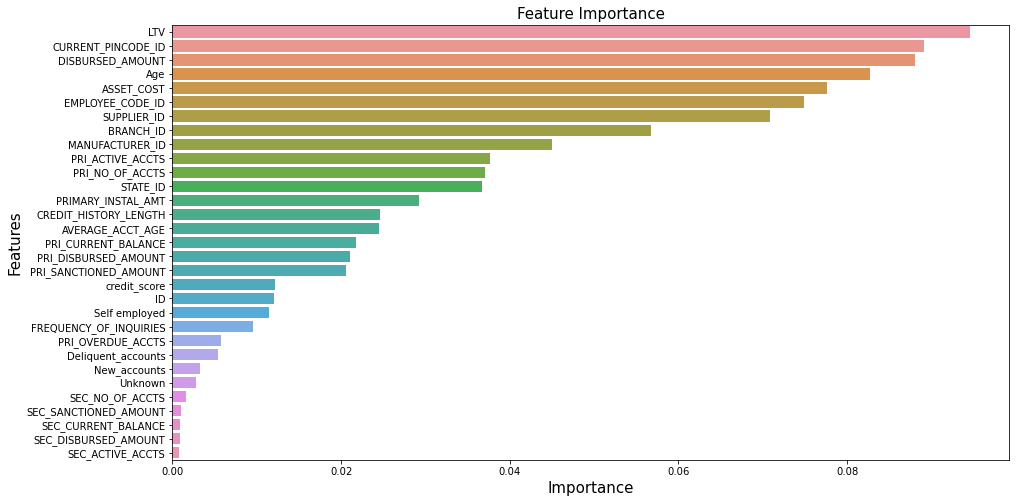

In [69]:
important_features = pd.DataFrame({'Features': x_train.columns, 
                                   'Importance': rf_model.feature_importances_})

important_features = important_features.sort_values('Importance', ascending = False)

sns.barplot(x = 'Importance', y = 'Features', data = important_features)


plt.title('Feature Importance', fontsize = 15)
plt.xlabel('Importance', fontsize = 15)
plt.ylabel('Features', fontsize = 15)


plt.show()

In [70]:
important_features.head(10)

,Features,Importance
2,LTV,0.094517
6,CURRENT_PINCODE_ID,0.089113
0,DISBURSED_AMOUNT,0.087988
23,Age,0.082746
1,ASSET_COST,0.077619
8,EMPLOYEE_CODE_ID,0.074880
4,SUPPLIER_ID,0.070840
3,BRANCH_ID,0.056776
5,MANUFACTURER_ID,0.045002
10,PRI_ACTIVE_ACCTS,0.037634


**INTERPRETATION**

The above dataframe represents the important features which should be must in the data for predictions of defaults.


The above plot also represents the feature importances ordinally. we can see that LTV is the most important feature in the 
dataset.